# Step 1 — Transit observables from a TTV posterior

**Goal.** Turn a light-curve/TTV fit posterior of $(R_p/R_\star,\ \rho_{\star,\rm obs},\ b,\ P)$
into the full set of transit observables
$(\delta,\ a/R_\star,\ T_{14},\ T_{23},\ b,\ i_{\rm orb},\ P)$ that the ring-geometry
likelihood (steps 2–3) consumes.

## Why this step exists

The ring retrieval never touches a light curve. It is constrained by the *effective transit
observables* — the numbers a standard, ringless transit model reports. Those posteriors
"encode the effective transit observables that any ringed configuration must reproduce":
they are what a spherical-planet fit inferred, whether or not rings are present. This
notebook produces exactly that target.

## The asterodensity relations

A transit constrains the stellar density through Kepler's third law. With
$F_{(\pm)} \equiv (1 \pm \sqrt{\delta})$, Seager & Mallén-Ornelas (2003) give

$$\rho_{\star,\rm obs} = \frac{3\pi}{G P^{2}}\left(\frac{a}{R_\star}\right)^{3}_{\rm obs},$$

$$\left(\frac{a}{R_\star}\right)^{2}_{\rm obs} =
\frac{F_{(+)}^{2} - b_{\rm obs}^{2}\left[1 - \sin^{2}(\pi T_{14}/P)\right]}
     {\sin^{2}(\pi T_{14}/P)},$$

$$b_{\rm obs}^{2} = \frac{F_{(-)}^{2}
  - \left[\sin^{2}(\pi T_{23}/P)/\sin^{2}(\pi T_{14}/P)\right] F_{(+)}^{2}}
  {1 - \sin^{2}(\pi T_{23}/P)/\sin^{2}(\pi T_{14}/P)}.$$

These hold for non-grazing transits ($b < 1 - p$), a planet much smaller than its star
($p \ll 1$), and durations much shorter than the period ($T_{14}/P \ll 1$) — all satisfied
by the Kepler-51 planets.

**A distinction worth keeping straight.** $T_{14}$, $T_{23}$ and $(a/R_\star)_{\rm obs}$ here
are *measured* quantities, inferred from the photometry under the ringless model. In step 2
the forward model computes its own $T_{14}^{\rm geo}$, $T_{23}^{\rm geo}$ and
$(a/R_\star)_{\rm geo}$ from a ring configuration. The inference compares the two. They are
different objects and the notebooks keep them apart.

## What runs here

| Section | What it does |
|---|---|
| §1 | Case configuration — the only cell you edit for a new target |
| §2 | Derive observables per segment, combine segments, save |
| §3 | Posterior summary and the observables figure |
| §4 | Optional, case-specific ring-stability context |

The computation itself lives in
[`photoring.observables`](photoring/observables.py); this notebook is a thin, documented
driver over it.


## 0. Environment

In [1]:
# ── Bootstrap: make the sibling packages importable without installation ────
# The pipeline uses three packages that live in the repository, uninstalled:
#   exorings, geotrans   (repo root)      photoring   (pipeline/)
# We locate the repo root and pipeline/ robustly from the current working dir
# (Jupyter / nbconvert / papermill all run notebooks from pipeline/).
import sys, pathlib
_HERE   = pathlib.Path.cwd().resolve()
_cands  = [_HERE, *_HERE.parents]
_NB_DIR = next((c for c in _cands if (c / "photoring").is_dir()), _HERE)
_REPO   = next((c for c in _cands if (c / "exorings").is_dir()), _NB_DIR.parent)
for _p in (str(_REPO), str(_NB_DIR)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root :", _REPO)
print("pipeline  :", _NB_DIR)

repo root : /home/numpaque/AppPR
pipeline  : /home/numpaque/AppPR/pipeline


In [2]:
import numpy as np
import pandas as pd
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
from photoring.observables import (
    load_posterior, derive_observables, save_observables, combine_segments,
)
import photoring.plotting as plot
plot.apply_style()
print("photoring ready.")

photoring ready.


## 1. Case configuration  ← edit here for your target

`CASE` selects the case directory `pipeline/<CASE>/`. `PLANET_TTV` lists the raw TTV file(s)
per planet, **relative to** `pipeline/<CASE>/inputs/ttv/`.

**On multiple files per planet.** A planet with many observed epochs can make a single
nested-sampling run intractable, because every epoch contributes its own mid-transit time as
a free parameter. The workaround is to split the light curve into independent temporal
segments and fit each separately — Kepler-51 b needed three, Kepler-51 d fitted in one go.
List every segment; §2 combines them.

To run your **own** target: copy `pipeline/kepler_51/` to `pipeline/<your_case>/`, drop your
TTV files into `inputs/ttv/`, and set `CASE`, `PLANET_TTV` and `COLS` below. `COLS` maps your
file's column order onto the four quantities the derivation needs.


In [3]:
CASE = "kepler_51"
paths = pr.CasePaths(CASE)

# Raw TTV posterior file(s) per planet, relative to inputs/ttv/.
# Several files = several independent light-curve segments (combined in section 2).
PLANET_TTV = {
    "b": ["Kepler-51b/TTVplan1-post_equal_weights.dat",
          "Kepler-51b/TTVplan2-post_equal_weights.dat",
          "Kepler-51b/TTVplan3-post_equal_weights.dat"],
    "d": ["Kepler-51d/TTVplan-post_equal_weights.dat"],
}

# Column indices in the TTV files: Rp/R*, rho*[kg/m3], b, P[days], t_mid, ..., logL(last).
COLS = dict(col_p=0, col_rho=1, col_b=2, col_per=3, col_tmid=4, col_logl=-1)

# Seed for the segment-combination resampling draw (reproducibility).
SEGMENT_SEED = 42

print("case:", CASE, "| planets:", {k: len(v) for k, v in PLANET_TTV.items()}, "segment(s) each")

case: kepler_51 | planets: {'b': 3, 'd': 1} segment(s) each


## 2. Derive and save observables

For each planet: derive the observables per segment, combine the segments, and write the
result to `inputs/observables/<CASE>_<planet>_observables.dat`.

### How segments are combined

The segments are independent posteriors over **the same** transit-shape parameters, so the
combined posterior is their **product**:

$$p_{\rm comb}(\boldsymbol\theta) \;\propto\; \prod_{k} p_{k}(\boldsymbol\theta).$$

`combine_segments` evaluates that product by importance sampling: the pooled samples serve
as the proposal, each is weighted by the product of every segment's KDE evaluated there, and
the weighted set is resampled to equal weight. Two alternatives that look tempting are both
wrong, and neither is offered:

- **pooling** (concatenating the segments) yields their *average*, not their product — it
  represents "one segment drawn at random", not "all segments simultaneously";
- **keeping one segment** discards most of the data.

Observables are re-derived **after** combining, from the combined native parameters, so
$\delta$, $a/R_\star$, $T_{14}$ and $T_{23}$ remain mutually consistent.

### Reading the diagnostics

The function prints two things worth looking at:

- **Pairwise tension**, $|{\rm med}_i - {\rm med}_j| / \sqrt{\sigma_i^2 + \sigma_j^2}$ per
  parameter. Above $\sim 2\sigma$ means a systematic difference between epochs rather than
  statistical scatter. For Kepler-51 b this is *expected* in $T_{14}$, $T_{23}$ and
  $\rho_{\star,\rm obs}$: the planet shows large-amplitude TTVs, so different stretches of
  the light curve sample different stages of the system's dynamical evolution.
- **Effective sample size** (Kish, $1/\sum w^2$), overall and per pair. A small ESS relative
  to the proposal means a few samples carry nearly all the weight and the combined posterior
  is noisy; the per-pair values identify which segment is most at odds with the rest.


In [4]:
obs_by_planet = {}

for planet, files in PLANET_TTV.items():
    print(f"\n{'#' * 62}\n#  Planet {planet}\n{'#' * 62}")
    segs = [derive_observables(load_posterior(paths.ttv_dir / f, **COLS)) for f in files]

    # Product of the segment posteriors, by importance sampling (single segment: no-op).
    obs_final, diag = combine_segments(segs, seed=SEGMENT_SEED)

    obs_by_planet[planet] = obs_final
    out = save_observables(obs_final, paths.observables_file(planet))
    print(f"\n  -> {paths.observables_file(planet).name}  {out.shape}")


##############################################################
#  Planet b
##############################################################
  Combining 3 segment(s) by importance sampling
  Segment 1: 36403 valid samples
  Segment 2: 38970 valid samples
  Segment 3: 42526 valid samples

-- Consistency: pairwise tension between segments ------------
  Param             1v2        1v3        2v3
  p            0.42s      0.77s      1.30s   
  rho_obs      0.04s      0.97s      0.96s   
  b            0.04s      0.51s      0.53s   

  Tension > 2 sigma indicates a systematic difference between epochs
  (e.g. starspots, or TTVs sampling different dynamical states).

-- 3-D KDE per segment in standardised native space --------
  Segment 1: Scott bandwidth h=0.2231  (n=36403, d=3)
  Segment 2: Scott bandwidth h=0.2209  (n=38970, d=3)
  Segment 3: Scott bandwidth h=0.2182  (n=42526, d=3)

-- Weight diagnostics ----------------------------------------
  [Product of 3 segments]
    N_eff = 17757

## 3. Posterior summary and figures

Three figures come out of this step, all of them also used in the manuscript:

1. **Observable posteriors** — one row per planet, one column per observable, with the
   median and 68% interval marked and published values overlaid for comparison. Literature
   scatter that exceeds the individual error bars is informative in itself: for the transit
   depth it points to unocculted stellar activity (Kepler-51 is young and magnetically
   active), and the impact parameter is the least constrained observable because Kepler's
   ~30-minute cadence smears exactly the ingress/egress slopes that carry chord geometry.
2. **Asterodensity profiling** — the density anomaly. Under the standard transit model every
   planet of a system must give the *same* $\rho_{\star,\rm obs}$, so a disagreement between
   planets, or against an independent stellar-density measurement, means the standard model
   is missing something about the transit geometry. Candidate causes: unmodelled starspots,
   incomplete system architecture, or **rings** — the hypothesis steps 2–3 test.
3. **Segment consistency** (multi-segment planets only) — each segment's posterior against
   the combination, the visual counterpart of the tension diagnostics above.


In [5]:
def summary(obs, planet):
    print(f"\n=== Planet {planet} — observable posterior summary ===")
    for key in ["p", "delta", "aR", "P", "b", "i_orb", "T14", "T23"]:
        v = obs[key].dropna().values
        print(f"  {key:>6}:  mean={v.mean():>10.5f}  std={v.std():>9.5f}  median={np.median(v):>10.5f}")

for planet, obs in obs_by_planet.items():
    summary(obs, planet)


=== Planet b — observable posterior summary ===
       p:  mean=   0.07048  std=  0.00032  median=   0.07049
   delta:  mean=   0.00497  std=  0.00004  median=   0.00497
      aR:  mean=  64.05907  std=  0.79750  median=  64.26643
       P:  mean=  45.15536  std=  0.00000  median=  45.15536
       b:  mean=   0.12618  std=  0.07215  median=   0.11576
   i_orb:  mean=  89.88638  std=  0.06660  median=  89.89681
     T14:  mean=   5.71140  std=  0.02502  median=   5.70809
     T23:  mean=   4.94367  std=  0.02354  median=   4.94141

=== Planet d — observable posterior summary ===
       p:  mean=   0.09533  std=  0.00077  median=   0.09531
   delta:  mean=   0.00909  std=  0.00015  median=   0.00908
      aR:  mean= 124.77531  std=  2.69755  median= 124.82271
       P:  mean= 130.17803  std=  0.00000  median= 130.17803
       b:  mean=   0.25311  std=  0.09542  median=   0.26959
   i_orb:  mean=  89.88282  std=  0.04599  median=  89.87624
     T14:  mean=   8.45878  std=  0.03685  media

  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/observables/kepler_51_observables.png
  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/observables/kepler_51_rho_obs_comparison.png


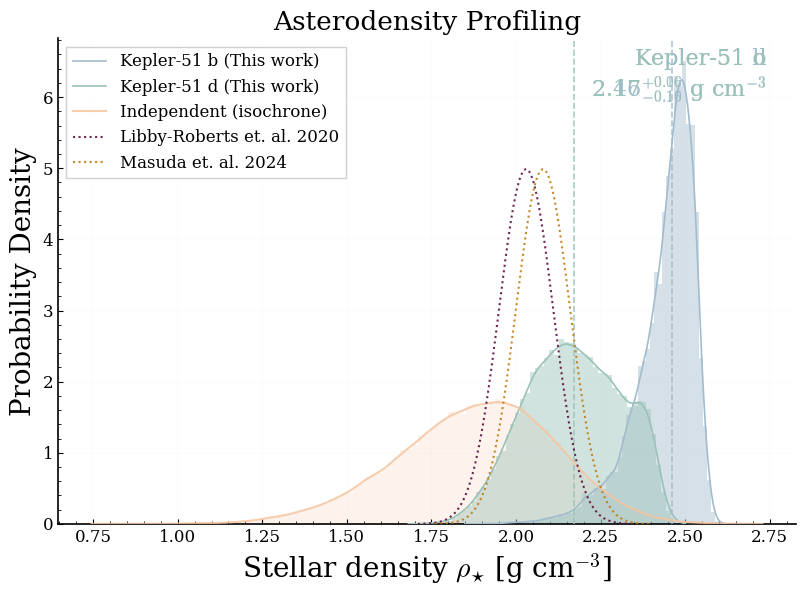

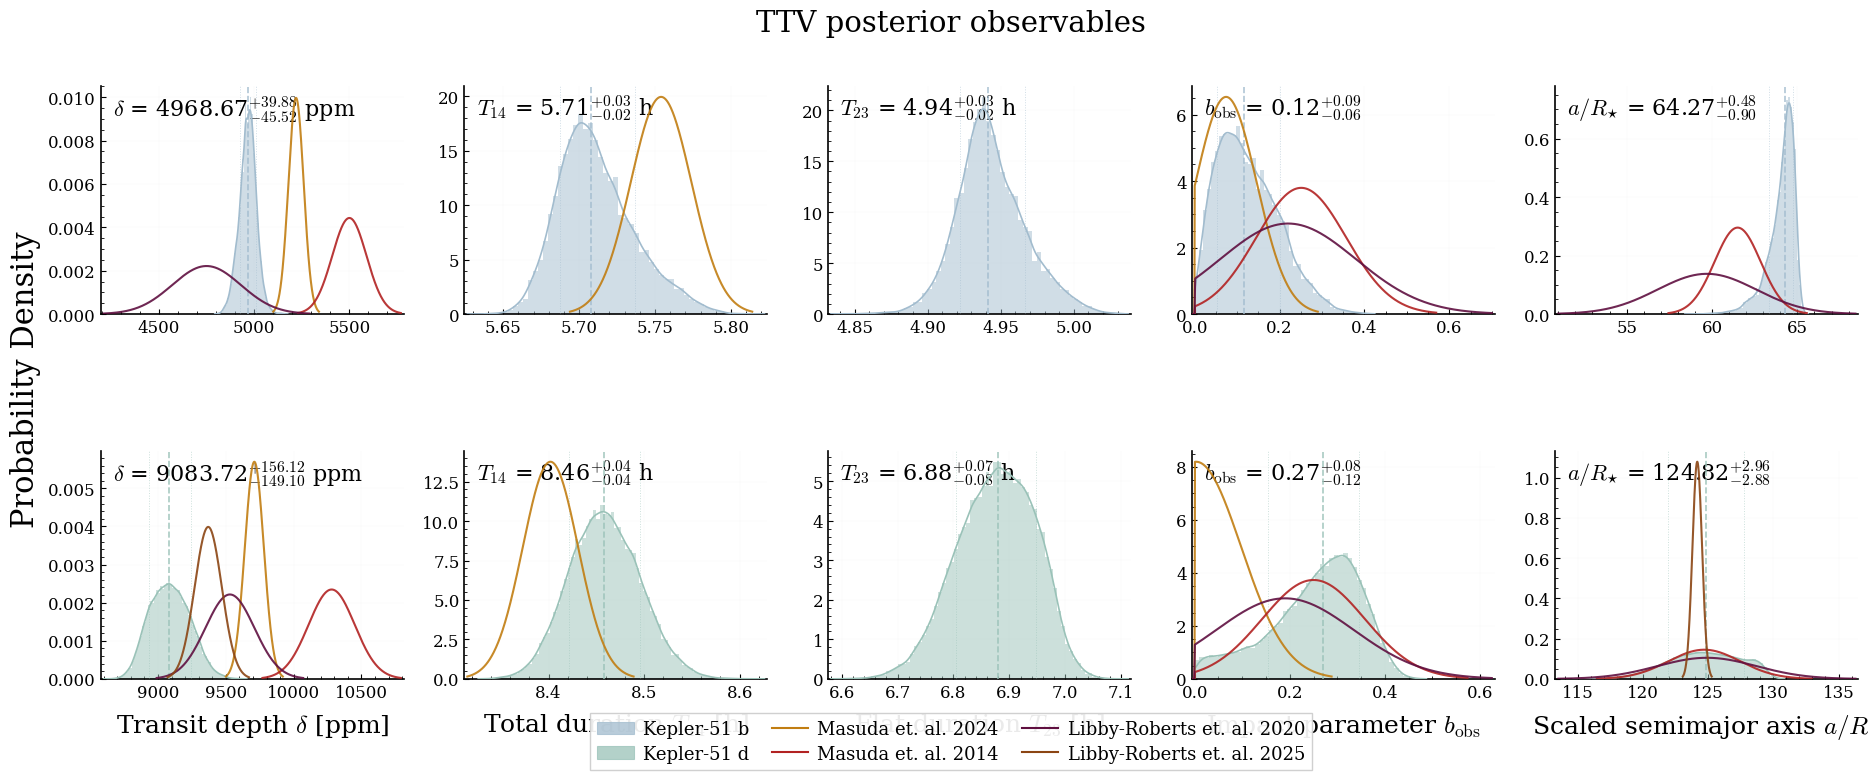

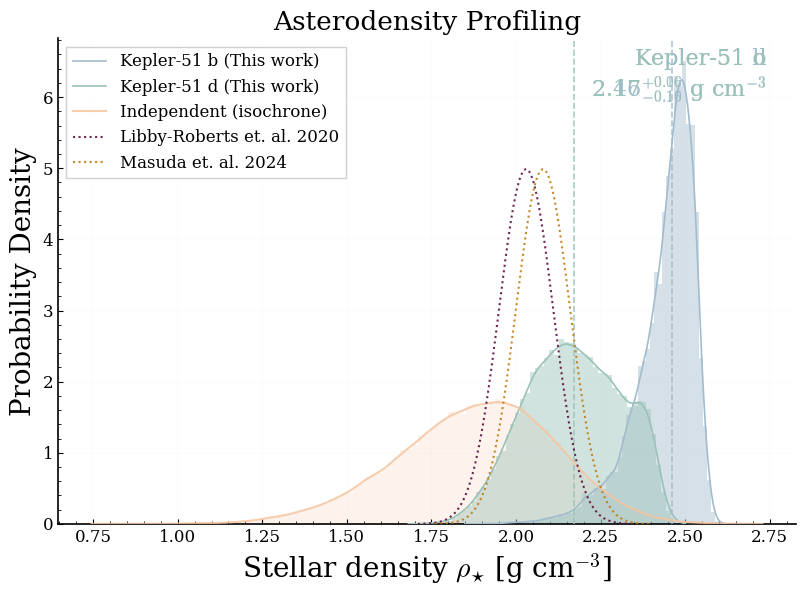

In [6]:
from photoring.io import load_observables
from photoring import literature

ttv_by_planet = {pl: load_observables(paths.observables_file(pl)) for pl in PLANET_TTV}

# Figure 1 — observable posteriors, rows = planets, with literature overlays.
plot.plot_observable_posteriors(
    ttv_by_planet,
    keys=["delta", "T14", "T23", "b_obs", "aR"],
    lit=literature.observables(CASE),
    paths=paths, run_tag=f"{CASE}_observables",
    title="TTV posterior observables",
)

# Figure 2 — asterodensity profiling: the stellar-density anomaly.
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3
plot.plot_asterodensity_profiling(
    ttv_by_planet,
    rho_true_samples=rho_true_samples,
    lit_rho=literature.rho_star(CASE),
    paths=paths, run_tag=f"{CASE}_rho_obs_comparison",
    title="Asterodensity Profiling",
)

  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/observables/kepler_51_b_observables_segments.png


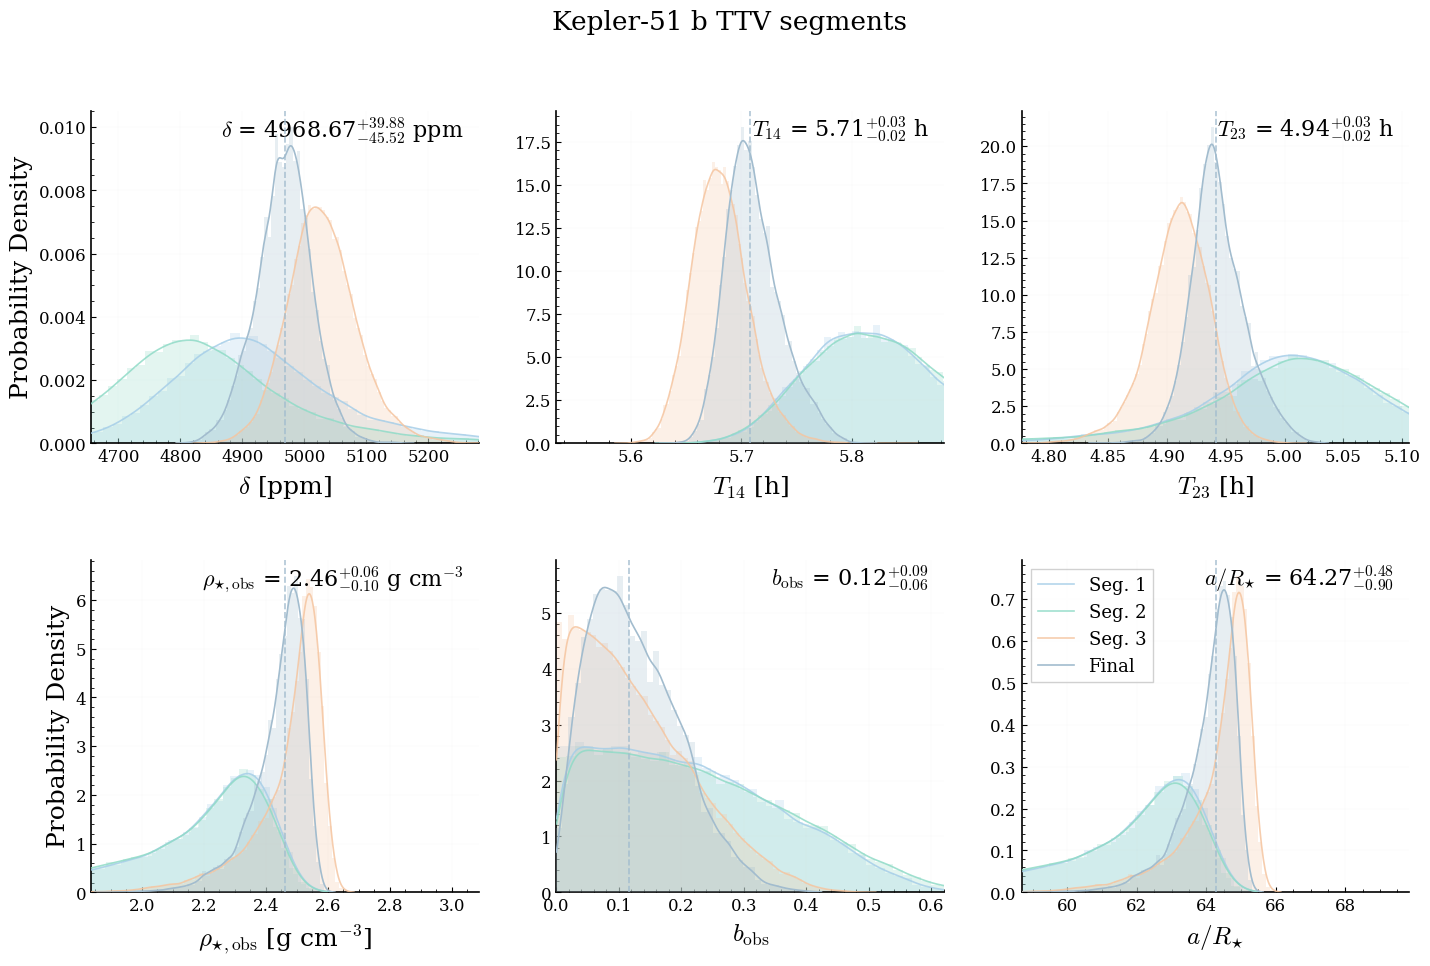

In [7]:
# Figure 3 — segment consistency, for planets that needed several segments.
for planet, files in PLANET_TTV.items():
    if len(files) < 2:
        continue
    segs = [derive_observables(load_posterior(paths.ttv_dir / f, **COLS)) for f in files]
    plot.plot_segment_consistency(
        segs, obs_by_planet[planet],
        keys=["delta", "T14", "T23", "rho_obs", "b_obs", "aR"],
        paths=paths, run_tag=f"{CASE}_{planet}_observables_segments",
        title=f"{plot.PLANET_LABELS.get(planet, planet)} TTV segments",
    )

## 4. Optional diagnostics — ring-stability context (Kepler-51)

The following is **case-specific** commentary, not part of the core pipeline: it compares each
planet's Hill radius (dynamical stability outer bound) and Roche radius (tidal inner bound for
ring material) to gauge whether rings could plausibly survive. Adapt the stellar/planet masses
and radii for your own target, or delete this section.

In [8]:
import astropy.constants as c
import astropy.units as u

# Kepler-51 system properties (Masuda 2014; Libby-Roberts 2020)
M_s, R_s = 0.96 * c.M_sun, 0.87 * c.R_sun
props = {  # planet: (mass, radius)
    "b": (6.7 * c.M_earth, 6.83 * c.R_earth),
    "d": (5.6 * c.M_earth, 9.32 * c.R_earth),
}
rho_ring = {"icy": 1.0e3 * u.kg / u.m**3, "dusty": 3.0e3 * u.kg / u.m**3}

for planet, (m_p, R_p) in props.items():
    if planet not in obs_by_planet:
        continue
    aR = obs_by_planet[planet]["aR"].dropna().values.mean()
    R_H = aR * R_s * (m_p / (3 * M_s)) ** (1 / 3)                 # Hill radius
    rho_p = (m_p / (4 / 3 * np.pi * R_p ** 3)).to(u.kg / u.m**3)  # planet bulk density
    print(f"\nPlanet {planet}:  R_Hill = {float((R_H / R_p).decompose()):.1f} Rp")
    for kind, rho_r in rho_ring.items():
        R_roche = R_p * (2 * rho_p / rho_r) ** (1 / 3)            # Roche radius (fluid)
        print(f"    R_Roche ({kind:5s} rings) = {float((R_roche / R_p).decompose()):.2f} Rp")


Planet b:  R_Hill = 17.0 Rp
    R_Roche (icy   rings) = 0.61 Rp
    R_Roche (dusty rings) = 0.43 Rp

Planet d:  R_Hill = 22.9 Rp
    R_Roche (icy   rings) = 0.42 Rp
    R_Roche (dusty rings) = 0.29 Rp


---
**Next:** step 2 builds the KDE likelihood from these observables and samples the ring geometry —
[`02_inference_dynesty.ipynb`](02_inference_dynesty.ipynb) (nested sampling, gives $\ln\mathcal{Z}$)
or [`02_inference_emcee.ipynb`](02_inference_emcee.ipynb) (MCMC).